Question 1 : Charger les différents datasets avec pandas

In [1]:
import pandas as pd

DATA_DIR = r"C:\Users\KOURO\Desktop\5MLRE\ml-latest-small"

ratings_df = pd.read_csv(f"{DATA_DIR}/ratings.csv") # userId, movieId, rating, timestamp
movies_df  = pd.read_csv(f"{DATA_DIR}/movies.csv")      # movieId, title, genres
tags_df    = pd.read_csv(f"{DATA_DIR}/tags.csv")        # userId, movieId, tag, timestamp
links_df   = pd.read_csv(f"{DATA_DIR}/links.csv")       # movieId, imdbId, tmdbId


Le dataset contient 4 fichiers CSV décrivant les notations et tags
de films par des utilisateurs de MovieLens.

| Fichier       | Contenu                                       |
|---------------|-----------------------------------------------|
| `ratings.csv` | Une ligne par note (userId, movieId, rating) |
| `movies.csv`  | Métadonnées des films (titre, genres)        |
| `tags.csv`    | Tags libres posés par les utilisateurs       |
| `links.csv`   | Identifiants externes (IMDb, TMDb)           |

question 2 : Combien de films sont concernés par cette étude ? Combien d'utilisateurs ?

In [3]:
# Nombre d'utilisateurs uniques
n_users = ratings_df["userId"].nunique()
print(f"Nombre d'utilisateurs : {n_users}")

# Nombre de films uniques (dans movies.csv)
n_movies = movies_df["movieId"].nunique()
print(f"Nombre de films : {n_movies}")

# Bonus
n_ratings = len(ratings_df)
n_movies_rated = ratings_df["movieId"].nunique()
print(f"Nombre total de notes : {n_ratings}")
print(f"Films ayant au moins une note : {n_movies_rated}")

Nombre d'utilisateurs : 610
Nombre de films : 9742
Nombre total de notes : 100836
Films ayant au moins une note : 9724


**Analyse :** Le dataset comprend **610 utilisateurs** ayant noté
**9 742 films** pour un total de **100 836 notes**. Chaque utilisateur
a donc noté en moyenne ~165 films (100836 / 610), tandis que chaquefilm n'a reçu qu'environ10 notes en moyenne.

Question 3 : Matrice des notes + proportion de manquants

In [5]:
# Création de la matrice des notes (user x movie)
R = ratings_df.pivot_table(index="userId", columns="movieId", values="rating")

print(f"Dimensions : {R.shape[0]} utilisateurs x {R.shape[1]} films")

# Proportion de valeurs manquantes
total_cells = R.shape[0] * R.shape[1]
missing = R.isna().sum().sum()
pct_missing = 100 * missing / total_cells

print(f"Nombre total de cellules : {total_cells:,}")
print(f"Cellules manquantes (NaN) : {missing:,}")
print(f"Proportion de NaN         : {pct_missing:.2f} %")
print(f"Proportion de notes       : {100 - pct_missing:.2f} %")

Dimensions : 610 utilisateurs x 9724 films
Nombre total de cellules : 5,931,640
Cellules manquantes (NaN) : 5,830,804
Proportion de NaN         : 98.30 %
Proportion de notes       : 1.70 %


**Analyse :** La matrice fait **5 931 640 cellules**, dont**98.30 % sont manquantes**. Seules1.70 % des paires
utilisateur-film possibles ont effectivement reçu une note.
Cette extrême *sparsité* est caractéristique des systèmes de
recommandation et motive l'utilisation d'algorithmes专为
ces données creuses (collaborative filtering, factorisation matricielle).

Question 4 : Dictionnaires titre ↔ movieId

In [6]:
# Dictionnaire {movieId : title}
id_to_title = dict(zip(movies_df["movieId"], movies_df["title"]))

# Dictionnaire inverse {title : movieId}
title_to_id = {title: mid for mid, title in id_to_title.items()}

# Vérification
print(f"Nombre de paires : {len(id_to_title):,}")
print("\nExemples title -> movieId :")
for t in ["Toy Story (1995)", "Pulp Fiction (1994)", "Forrest Gump (1994)"]:
    print(f"  {t!r:35s} -> {title_to_id[t]}")

print("\nExemples movieId -> title :")
for m in [1, 296, 356, 527]:
    print(f"  {m:>5} -> {id_to_title[m]!r}")

Nombre de paires : 9,742

Exemples title -> movieId :
  'Toy Story (1995)'                  -> 1
  'Pulp Fiction (1994)'               -> 296
  'Forrest Gump (1994)'               -> 356

Exemples movieId -> title :
      1 -> 'Toy Story (1995)'
    296 -> 'Pulp Fiction (1994)'
    356 -> 'Forrest Gump (1994)'
    527 -> "Schindler's List (1993)"


Question 5 :  Étude de la variable rating

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64
Mode : 4.0
Skewness : -0.6372
Kurtosis   : 0.1233


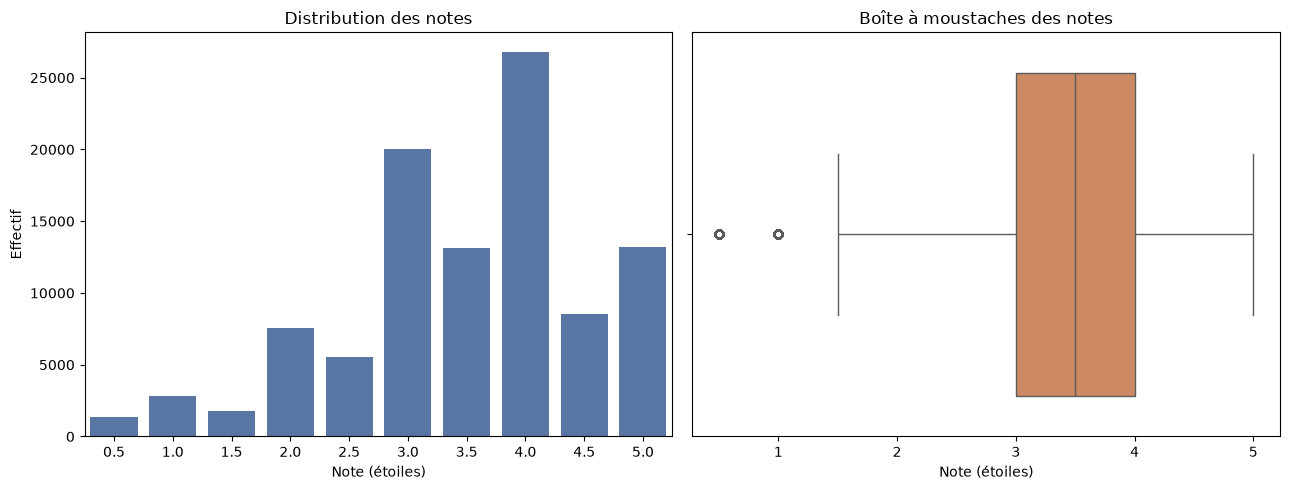

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Paramètres statistiques ---
r = ratings_df["rating"]
print(r.describe())
print(f"Mode : {r.mode().iloc[0]}")
print(f"Skewness : {r.skew():.4f}")
print(f"Kurtosis   : {r.kurt():.4f}")

# --- Représentations graphiques ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme des notes
sns.countplot(x=r, order=sorted(r.unique()), color="#4C72B0", ax=axes[0])
axes[0].set_title("Distribution des notes")
axes[0].set_xlabel("Note (étoiles)")
axes[0].set_ylabel("Effectif")

# Boîte à moustaches
sns.boxplot(x=r, color="#DD8452", ax=axes[1])
axes[1].set_title("Boîte à moustaches des notes")
axes[1].set_xlabel("Note (étoiles)")

plt.tight_layout()
plt.show()

**Analyse :**
- Moyenne (3.50) ≈ médiane (3.5), donc la distribution est
 globalement centrée, mais le mode à **4.0** montre une préférence
  pour les notes positives.
- Skewness = **-0.64** : la distribution est étalée à gauche,
  avec une minorité de notes très basses (0.5, 1.0) qui tirent
  la moyenne en dessous de la médiane.
- Les notes0.5 et 1.0 apparaissent comme outliers dans le boxplot,
  confirmant que les utilisateurs notent rarement très mal.

Question 6 : Nombre de notes par film

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: n_ratings, dtype: float64
Skewness : 5.24
Kurtosis : 38.97


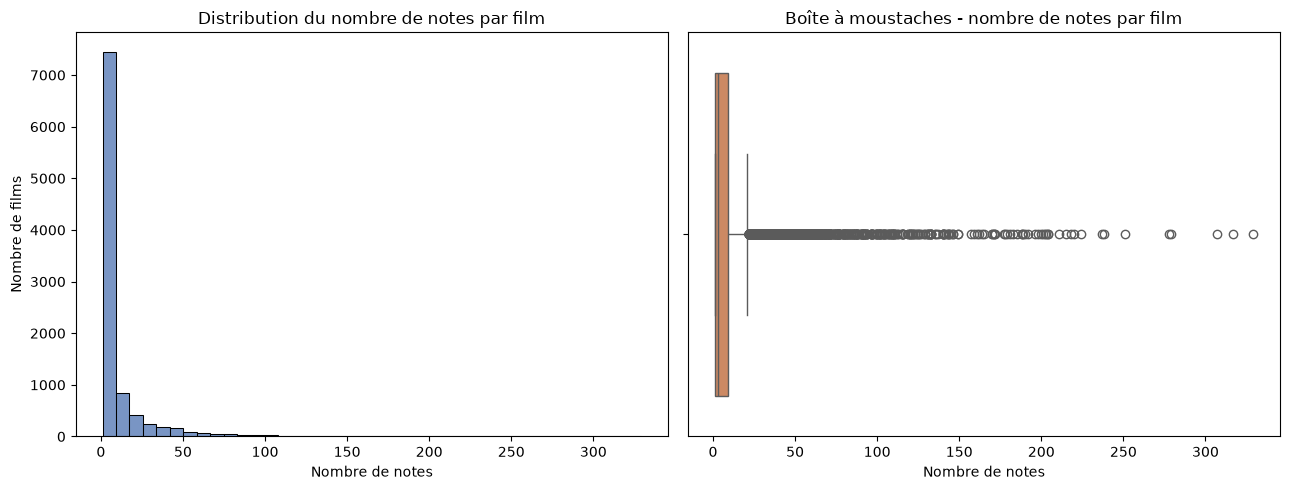

In [8]:
# Nombre de notes par film
ratings_per_movie = ratings_df.groupby("movieId")["rating"].count()
ratings_per_movie.name = "n_ratings"

# On rattache les titres pour la lisibilité
ratings_per_movie = ratings_per_movie.to_frame().join(
    movies_df.set_index("movieId")[["title"]]
)

# Paramètres statistiques
print(ratings_per_movie["n_ratings"].describe())
print(f"Skewness : {ratings_per_movie['n_ratings'].skew():.2f}")
print(f"Kurtosis : {ratings_per_movie['n_ratings'].kurt():.2f}")

# Représentations graphiques
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(ratings_per_movie["n_ratings"], bins=40, color="#4C72B0", ax=axes[0])
axes[0].set_title("Distribution du nombre de notes par film")
axes[0].set_xlabel("Nombre de notes")
axes[0].set_ylabel("Nombre de films")

sns.boxplot(x=ratings_per_movie["n_ratings"], color="#DD8452", ax=axes[1])
axes[1].set_title("Boîte à moustaches - nombre de notes par film")
axes[1].set_xlabel("Nombre de notes")

plt.tight_layout()
plt.show()

**Analyse :**
- Médiane = **3 notes** par film, mais moyenne = **10.4** :
  énorme écart → quelques films cumulent des centaines de notes.
- Skewness = **5.24**, kurtosis = **38.97** : queue droite très lourde,
  c'est la *long tail* typique des plateformes de contenu (Forrest Gump
  cumule 329 notes alors que la majorité des films en ont moins de 5).
- 75 % des films ont 9 notes ou moins → la majorité du catalogue est
  quasiment *invisible* pour les systèmes de recommandation.

Question 7 :  Rang par nombre de notes + top 50

In [9]:
# Calcul du rang (1 = le plus de notes)
ratings_per_movie["rank"] = ratings_per_movie["n_ratings"] \
    .rank(method="min", ascending=False) \
    .astype(int)

# Top 50
top50 = ratings_per_movie.sort_values("n_ratings", ascending=False).head(50)
print(top50.to_string())

         n_ratings                                                                           title  rank
movieId                                                                                                 
356            329                                                             Forrest Gump (1994)     1
318            317                                                Shawshank Redemption, The (1994)     2
296            307                                                             Pulp Fiction (1994)     3
593            279                                                Silence of the Lambs, The (1991)     4
2571           278                                                              Matrix, The (1999)     5
260            251                                       Star Wars: Episode IV - A New Hope (1977)     6
480            238                                                            Jurassic Park (1993)     7
110            237                                     

**Analyse :** Le top 50 est dominé par les blockbusters des années 90
(Forrest Gump, Pulp Fiction, Matrix, Star Wars...) et les films
culte grand public. Ces films cumulent un grand nombre de notes car
ils sont largement connus et accessibles. On observe des ex-aequo(par exemple rang 14 pour American Beauty et Usual Suspects avec
204 notes chacun), ce qui justifie la méthode `min`.

Question 8 : Note moyenne par film

count    9724.000000
mean        3.262448
std         0.869874
min         0.500000
25%         2.800000
50%         3.416667
75%         3.911765
max         5.000000
Name: mean_rating, dtype: float64
Skewness : -0.6260
Kurtosis : 0.5367


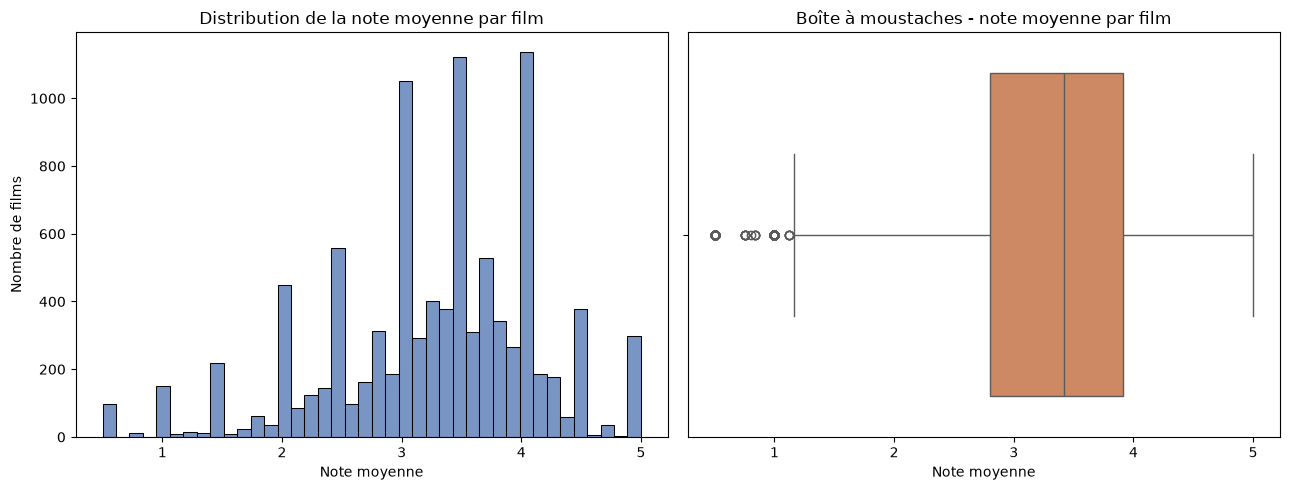

In [10]:
# Note moyenne par film
mean_per_movie = ratings_df.groupby("movieId")["rating"].mean()
mean_per_movie.name = "mean_rating"

# Jointure avec les titres
mean_per_movie = mean_per_movie.to_frame().join(
    movies_df.set_index("movieId")[["title", "genres"]]
)

# Paramètres statistiques
print(mean_per_movie["mean_rating"].describe())
print(f"Skewness : {mean_per_movie['mean_rating'].skew():.4f}")
print(f"Kurtosis : {mean_per_movie['mean_rating'].kurt():.4f}")

# Graphiques
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(mean_per_movie["mean_rating"], bins=40, color="#4C72B0", ax=axes[0])
axes[0].set_title("Distribution de la note moyenne par film")
axes[0].set_xlabel("Note moyenne")
axes[0].set_ylabel("Nombre de films")

sns.boxplot(x=mean_per_movie["mean_rating"], color="#DD8452", ax=axes[1])
axes[1].set_title("Boîte à moustaches - note moyenne par film")
axes[1].set_xlabel("Note moyenne")

plt.tight_layout()
plt.show()

**Analyse :**
- Moyenne des moyennes = **3.26**, médiane = **3.42**.
- Skewness = **-0.63** : la distribution des notes moyennes est
  asymétrique à gauche, avec un excès de films très bien notés.
- Les pics visibles aux valeurs rondes (0.5, 1, 1.5, 5) sur l'histogramme
  correspondent aux films notés une seule fois, dont la "moyenne"
  est en fait leur unique note. Ces films-là **gonflent artificiellement**
  les extrêmes de la distribution et justifient le filtrage de la Q9.

Question 9 : Rang par note moyenne + top 50

In [12]:
# Rang brut
mean_per_movie["rank"] = (
    mean_per_movie["mean_rating"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# --- Top 50 brut (tous films) ---
top50_brut = mean_per_movie.sort_values("mean_rating", ascending=False).head(50)
print("=== Top 50 brut (tous films) ===")
print(top50_brut[["rank", "mean_rating", "title"]].to_string())

# --- Top 50 avec au moins 20 notes (plus fiable) ---
ratings_per_movie = ratings_df.groupby("movieId")["rating"].count()
ratings_per_movie.name = "n_ratings"

mean_per_movie = mean_per_movie.join(ratings_per_movie)

top50_filtre = (
    mean_per_movie[mean_per_movie["n_ratings"] >= 20]
    .sort_values("mean_rating", ascending=False)
    .head(50)
)
print("\n=== Top 50 avec au moins 20 notes ===")
print(top50_filtre[["mean_rating", "n_ratings", "title"]].to_string())

=== Top 50 brut (tous films) ===
         rank  mean_rating                                                                 title
movieId                                                                                         
187717      1          5.0                                      Won't You Be My Neighbor? (2018)
6983        1          5.0                                                      Jane Eyre (1944)
5328        1          5.0                                                           Rain (2001)
95843       1          5.0                                                Goodbye Charlie (1964)
3941        1          5.0                                        Sorority House Massacre (1986)
3940        1          5.0                                     Slumber Party Massacre III (1990)
3939        1          5.0                                      Slumber Party Massacre II (1987)
7815        1          5.0                                                   True Stories (198

**Analyse :**
- **Top brut** : complètement faussé par les films notés une seule fois  (rang 1 partagé par des dizaines de films à 5.0). Aucune valeur
  interprétable sans filtre.
- **Top ≥ 20 notes** : bien plus réaliste, on retrouve des classiques
  reconnus (*Brazil*, *Rosemary's Baby*, *Glory*, *Maltese Falcon*)
  avec des moyennes entre 4.15 et 4.18. Le filtrage par nombre minimal
  de notes est **indispensable** pour obtenir un classement significatif.

Question 10 : Reprendre Q6–Q9 par genre

In [13]:
import numpy as np

# --- Préparation : explosion des genres ---
movies_exploded = movies_df.copy()
movies_exploded["genres"] = movies_exploded["genres"].str.split("|")
movies_exploded = movies_exploded.explode("genres")

# Jointure avec les notes
genre_ratings = ratings_df.merge(
    movies_exploded[["movieId", "genres"]], on="movieId", how="inner"
)

# --- a. Nombre de notes par genre (≈ Q6) ---
genre_summary = (
    genre_ratings.groupby("genres")
    .agg(
        n_movies=("movieId", "nunique"),
        n_ratings=("rating", "count"),
        mean_rating=("rating", "mean"),
        median_rating=("rating", "median"),
        std_rating=("rating", "std"),
    )
    .sort_values("n_ratings", ascending=False)
)
print(genre_summary)

                    n_movies  n_ratings  mean_rating  median_rating  \
genres                                                                
Drama                   4349      41928     3.656184            4.0   
Comedy                  3753      39053     3.384721            3.5   
Action                  1828      30635     3.447984            3.5   
Thriller                1889      26452     3.493706            3.5   
Adventure               1262      24161     3.508609            3.5   
Romance                 1591      18124     3.506511            3.5   
Sci-Fi                   980      17243     3.455721            3.5   
Crime                   1196      16681     3.658294            4.0   
Fantasy                  778      11834     3.491001            3.5   
Children                 664       9208     3.412956            3.5   
Mystery                  573       7674     3.632460            4.0   
Horror                   977       7291     3.258195            3.5   
Animat

**Analyse :**
- **Par volume** : Drama (41 928) et Comedy (39 053) trustent le podium,
  ce sont les genres les plus produits et les plus consommés.
- **Par qualité** : **Film-Noir** (3.92), **Documentary** (3.80) et
  **War** (3.81) sont les mieux notés. Ce sont des genres de niche
  au public plus restreint mais très engagé.
- **Horror** est le genre le moins bien noté (3.26), possiblement
  car les déceptions sont plus marquées dans ce genre.
-  Un même film comptant pour plusieurs genres gonfle les volumes ;
  le total des notes par genre est donc supérieur au nombre réel  de notes (100 836).

=== Genres par nombre de notes ===
                    rank_n  n_movies  n_ratings
genres                                         
Drama                    1      4349      41928
Comedy                   2      3753      39053
Action                   3      1828      30635
Thriller                 4      1889      26452
Adventure                5      1262      24161
Romance                  6      1591      18124
Sci-Fi                   7       980      17243
Crime                    8      1196      16681
Fantasy                  9       778      11834
Children                10       664       9208
Mystery                 11       573       7674
Horror                  12       977       7291
Animation               13       610       6988
War                     14       381       4859
IMAX                    15       158       4145
Musical                 16       333       4138
Western                 17       167       1930
Documentary             18       438       1219
Film-

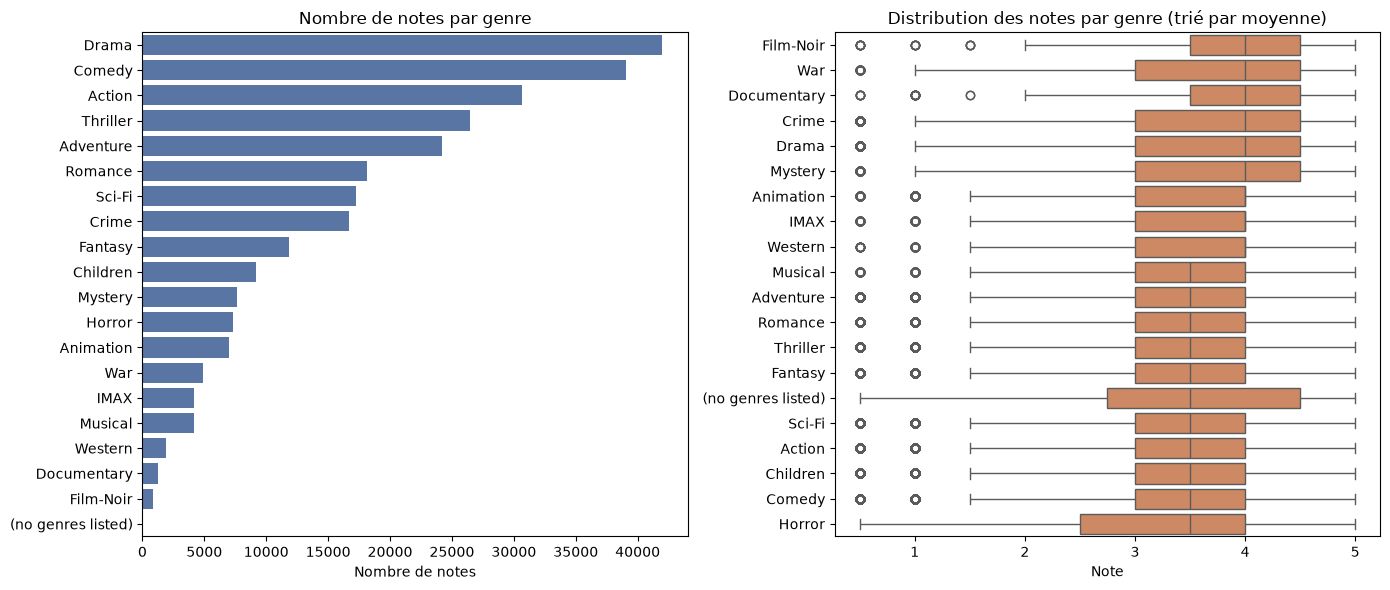

In [14]:
# --- b. Rang par nombre de notes (≈ Q7) ---
genre_summary["rank_n"] = (
    genre_summary["n_ratings"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# --- c. Classement par note moyenne (≈ Q9) ---
genre_rank_mean = (
    genre_summary[["mean_rating", "n_ratings", "n_movies"]]
    .sort_values("mean_rating", ascending=False)
)
genre_rank_mean["rank_mean"] = (
    genre_rank_mean["mean_rating"]
    .rank(method="min", ascending=False)
    .astype(int)
)

print("=== Genres par nombre de notes ===")
print(genre_summary[["rank_n", "n_movies", "n_ratings"]].to_string())

print("\n=== Genres par note moyenne ===")
print(genre_rank_mean.to_string())

# --- Graphiques ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order_n = genre_summary.sort_values("n_ratings", ascending=False).index
sns.countplot(
    data=genre_ratings, y="genres",
    order=order_n, color="#4C72B0", ax=axes[0]
)
axes[0].set_title("Nombre de notes par genre")
axes[0].set_xlabel("Nombre de notes")
axes[0].set_ylabel("")

order_m = genre_rank_mean.index
sns.boxplot(
    data=genre_ratings, y="genres", x="rating",
    order=order_m, color="#DD8452", ax=axes[1]
)
axes[1].set_title("Distribution des notes par genre (trié par moyenne)")
axes[1].set_xlabel("Note")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()